In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

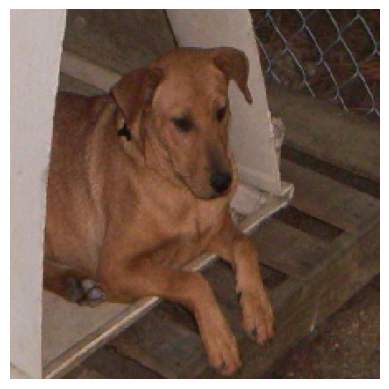

1/1 [==============================] - 2s 2s/step
예측:  [('n02087394', 'Rhodesian_ridgeback', 0.54290515), ('n02090379', 'redbone', 0.18797511), ('n02093991', 'Irish_terrier', 0.120005794)]


In [17]:
model = ResNet50(weights='imagenet')

img_path = 'dataset/Pet_images/train/dog/100.jpg'
img = image.load_img(img_path, target_size=(224, 224))

x = image.img_to_array(img)

plt.imshow(x.astype('uint8'))
plt.axis('off') # Hide grid lines and pixel axes
plt.show()

x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
print('예측: ', decode_predictions(preds, top=3)[0])

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNet, mobilenet
from tensorflow.keras.preprocessing import image

In [3]:
base_model = MobileNet(weights='imagenet', include_top=False)

x1 = base_model.output
x2 = layers.GlobalAveragePooling2D()(x1)
x3 = layers.Dense(1024, activation='relu')(x2)
x4 = layers.Dense(1024, activation='relu')(x3)
x5 = layers.Dense(512, activation='relu')(x4)
preds = layers.Dense(2, activation='softmax')(x5)

model = models.Model(inputs=base_model.input, outputs=preds)

for layer in model.layers[:20]:
    layer.trainable = False
for layer in model.layers[20:]:
    layer.trainable = True

In [6]:
train_datagen = image.ImageDataGenerator(preprocessing_function=mobilenet.preprocess_input)

train_generator = train_datagen.flow_from_directory(
    'dataset/Pet_images/train/',
    target_size = (128, 128),
    color_mode = 'rgb',
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = True)

model.compile(
    optimizer='Adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy'])

step_size_train = train_generator.n // train_generator.batch_size

model.fit(
    train_generator,
    steps_per_epoch = step_size_train,
    epochs = 5)

Found 2000 images belonging to 2 classes.
Epoch 1/5
62/62 [==============================] - 57s 850ms/step - loss: 0.3307 - accuracy: 0.8755
Epoch 2/5
62/62 [==============================] - 51s 819ms/step - loss: 0.1585 - accuracy: 0.9421
Epoch 3/5
62/62 [==============================] - 53s 850ms/step - loss: 0.0924 - accuracy: 0.9670
Epoch 4/5
62/62 [==============================] - 56s 906ms/step - loss: 0.0675 - accuracy: 0.9771
Epoch 5/5
62/62 [==============================] - 65s 1s/step - loss: 0.0835 - accuracy: 0.9705


In [7]:
test_generator = train_datagen.flow_from_directory(
    'dataset/Pet_images/test/',
    target_size = (128, 128),
    color_mode = 'rgb',
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = False)

test_loss, test_acc = model.evaluate(test_generator)

print("Test Loss: ", test_loss)
print("Test Accuracy: ", test_acc)

Found 200 images belonging to 2 classes.
7/7 [==============================] - 6s 392ms/step - loss: 0.2591 - accuracy: 0.9300
Test Loss:  0.25908079743385315
Test Accuracy:  0.9300000071525574
